# Dataset Preparation

In [3]:
import glob
import cv2
import numpy as np
import torch
import nibabel as nib
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms.functional import normalize
import torch.nn.functional as F
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import random
from PIL import Image
import os
from torchvision.transforms import v2
from torchvision.io import read_image
import copy

In [4]:
def read_data(data_path):
    
    file_list = glob.glob(data_path + '*') # this searches for ALL directories
    print(file_list)
    data = []
    for class_path in file_list:
        class_name = class_path.split("/")[-1]
        for vol_path in glob.glob(class_path + "/*.png"):
            data.append([vol_path, class_name])
    print(len(data))
    return data

In [5]:
# build dataloaders with pytorch
class MRIDataset(Dataset):
    
    def __init__(self,data,transform=None) -> None:
        
        self.transform = transform
        self.data = [(el, 'main') for el in data]
        
        self.normalization = v2.Compose([
                v2.ToImage(),
                v2.Resize((224,224)),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # typically from ImageNet
            ])
        
        if transform:
            self.data.extend([(el, 'augm1') for el in data if el[1] == 'AD']) #just for AD samples

            self.transform1 = v2.Compose([
                    v2.RandomRotation(degrees = 3)   #[-3,3]
                ])

        self.N_AD = 0
        self.N_MCI = 0
        self.N_CN = 0

        self.class_map = {'AD':0 , 'MCI':1 , 'CN' : 2}
        
        super().__init__()

    def __len__(self):
#         print("AD, MCI and CN numbers are:" , self.N_AD, self.N_MCI , self.N_CN)
        return len(self.data)

    def __getitem__(self, idx):
        
        vol_path, class_name = self.data[idx][0] # data now is a tuple first element is data path
        volume = read_image(vol_path) # C×H×W  [0-255]
        
        class_index = self.class_map[class_name]

        if class_index == 0:
            self.N_AD += 1
            
        if class_index == 1:
            self.N_MCI += 1
            
        if class_index == 2:
            self.N_CN += 1
            
        if self.transform and (self.data[idx][1] == 'augm1'): # I want to double samples in AD group to make the dataset balanced.
            augmented = self.transform1(volume)
            volume = augmented
            
        volume = self.normalization(volume) # for all of training and validation
        
        return volume , class_index

In [ ]:
data_path = '/kaggle/input/middleslices3way/MiddleSlices/'
data_items = read_data(data_path)

# Pretrained Customized Model

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, datasets, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [ ]:
# model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

In [ ]:
model

In [ ]:
# model.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(25088, 256),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(256, 3),
#             nn.Softmax(dim=1)
#         )
model.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1280, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 3),
            nn.Softmax(dim=1)
)

In [ ]:
for name, module in model.named_children():
    print(f"Layer Name: {name}, Layer Type: {module.__class__.__name__}")
    
    # Print children of the current module
    for sub_name, sub_module in module.named_children():
        print(f"    Sub-layer Name: {sub_name}, Sub-layer Type: {sub_module.__class__.__name__}")
        
        # Print children of the current sub-module
        for sub_sub_name, sub_sub_module in sub_module.named_children():
            print(f"        Sub-sub-layer Name: {sub_sub_name}, Sub-sub-layer Type: {sub_sub_module.__class__.__name__}")

In [ ]:
# for param in model.parameters():
#     param.requires_grad = True
    
# for param in model.classifier.parameters():
#     param.requires_grad = True
    
# for param in model.avgpool.parameters():
#     param.requires_grad = True
    
# for param in model.features[7].parameters():
#     param.requires_grad = True
# for param in model.features[6][9:15].parameters():
#     param.requires_grad = True    

In [ ]:
# Dictionary to store layer output shapes
# layer_outputs = {}

# # Define the hook function
# def hook_fn(module, input, output):
#     # Store the output shape
#     layer_outputs[module] = output.shape

# # Register the hook on each layer
# for name, layer in model.named_modules():
#     layer.register_forward_hook(hook_fn)

# # Forward a dummy input through the model to trigger the hooks
# dummy_input = torch.randn(2, 3, 384, 384)  # Batch size of 2
# model(dummy_input)

# # Print out each layer's output shape
# for layer, shape in layer_outputs.items():
#     print(f"{layer}: {shape}")

In [ ]:
# Dictionary to store layer output shapes with unique names
layer_outputs = {}

# Define the hook function
def hook_fn(name):
    def hook(module, input, output):
        # Store the output shape with the module name as a key
        layer_outputs[name] = output.shape
    return hook

# Register the hook on each sub-layer with unique names
for name, layer in model.named_modules():
    layer.register_forward_hook(hook_fn(name))

# Forward a dummy input through the model to trigger the hooks
dummy_input = torch.randn(2, 3, 384, 384)  # Batch size of 2 for EfficientNet V2
model(dummy_input)

# Print out each layer's output shape
for layer_name, shape in layer_outputs.items():
    print(f"{layer_name}: {shape}")


# Combination
I change Model type for each of single models and hybrid model

In [ ]:
!pip install accelerate evaluate datasets peft -q

In [ ]:
pip install --upgrade peft

In [ ]:
pip install transformers==4.34.0 peft==0.5.0 huggingface_hub==0.17.0

In [ ]:
pip install huggingface_hub

In [ ]:
pip install --upgrade transformers

In [ ]:
pip show transformers

In [2]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model

In [9]:
model_checkpoint = "google/vit-base-patch16-224"
label2id = {'AD':'0' , 'MCI':'1' , 'CN':'2'}
id2label = {'0':'AD','1':'MCI','2':'CN'}

In [11]:
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
model.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 3),
            nn.Softmax(dim=1)
        )

In [13]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

In [14]:
# Define the config for LoRA adaptation
config = LoraConfig(
    r=8,
    lora_alpha=8,
    target_modules = ['key','query','value'],
    # target_modules=["vit.encoder.layer.10.attention.attention.key", "vit.encoder.layer.10.attention.attention.query", "vit.encoder.layer.10.attention.attention.value","vit.encoder.layer.11.attention.attention.key", "vit.encoder.layer.11.attention.attention.query", "vit.encoder.layer.11.attention.attention.value"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"],
    # layers_to_transform=[10, 11],  # Apply LoRA to layers 10 and 11
    # layers_pattern="encoder.layer.{layer}",  # Pattern to locate encoder layers
)

lora_model = get_peft_model(model, config)

In [15]:
lora_model

PeftModel(
  (base_model): LoraModel(
    (model): ViTForImageClassification(
      (vit): ViTModel(
        (embeddings): ViTEmbeddings(
          (patch_embeddings): ViTPatchEmbeddings(
            (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
          )
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): ViTEncoder(
          (layer): ModuleList(
            (0-11): 12 x ViTLayer(
              (attention): ViTSdpaAttention(
                (attention): ViTSdpaSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=768, out_features=8, bias=False)
                    )
                    (lora_B): ModuleDict(
               

In [ ]:
# Count the number of trainable parameters
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {trainable_params}")

In [17]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_v2_s

In [18]:
class EfficientNetFeatureExtractor(nn.Module):
    def __init__(self):
        super(EfficientNetFeatureExtractor, self).__init__()
        
        # Load EfficientNet V2 S pretrained model
        efficientnet = efficientnet_v2_s(weights="EfficientNet_V2_S_Weights.DEFAULT")
        
        # Extract only the first 3 blocks
        self.features = nn.Sequential(*efficientnet.features[:7])  # Use only blocks 0 to 6

    def forward(self, x):
        return self.features(x)

In [21]:
class EfficientNet_ViT_Hybrid(nn.Module):
    def __init__(self, vit_model, num_classes=3):
        super(EfficientNet_ViT_Hybrid, self).__init__()
        
        # Use the custom EfficientNet feature extractor
        self.feature_extractor = EfficientNetFeatureExtractor()
        
        # Custom Vision Transformer (ViT) model
        self.vit = vit_model
        
        # Projection layer to match ViT's input channels and size requirements
        self.projector = nn.Sequential(
            nn.Conv2d(256, 3, kernel_size=1),  # Adjust 64 channels to 3 channels
            nn.Upsample(size=(224, 224), mode='nearest')  # Resize to 224x224
        )

    def forward(self, x):
        # Pass input through the first 3 blocks of EfficientNet
        x = self.feature_extractor(x)
        
        # Project feature map to match ViT input format
        x = self.projector(x)
        
        # Pass the projected feature map through ViT
        x = self.vit(x)
        
        # If the output is not a tensor, access logits (or equivalent) if necessary
        if hasattr(x, "logits"):
            x = x.logits
        
        return x

In [22]:
hybrid_model = EfficientNet_ViT_Hybrid(lora_model, num_classes=3)
# hybrid_model = CNN_ViT_Hybrid(lora_model, num_classes=3)

### Test ###
# Example forward pass with random input
input_data = torch.randn(2, 3, 384, 384)  # Assuming input is of shape [batch, channels, height, width]
output = hybrid_model(input_data)

print("Output shape:", output.shape)  # Expected: [2, num_classes]

Output shape: torch.Size([2, 3])


In [23]:
hybrid_model

EfficientNet_ViT_Hybrid(
  (feature_extractor): EfficientNetFeatureExtractor(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=

In [ ]:
# Count the number of trainable parameters
trainable_params = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)

print(f"Number of trainable parameters: {trainable_params}")


In [ ]:
# Configuration options
k_folds = 5
num_epochs = 100
learning_rate = 1e-4
criterion = nn.CrossEntropyLoss()
batch_size = 32
# For fold results
results = []
metrics = []
best_model_metrics = None
best_model_state = None
best_fold = None
best_val_accuracy = 0

# Set fixed random number seed
torch.manual_seed(42)

dataset = data_items
# Define the K-fold Cross Validator
kfold = KFold(n_splits=k_folds, shuffle=True)

# Start print
print('--------------------------------')

# K-fold Cross Validation model evaluation
for fold, (train_ids, test_ids) in enumerate(kfold.split(dataset)):
    # Print
    print(f'FOLD {fold}')
    print('--------------------------------')
    
    train_data = [data_items[i] for i in train_ids]
    validation_data = [data_items[i] for i in test_ids]
    
    train_dataset = MRIDataset(train_data,transform=True)
    valid_dataset = MRIDataset(validation_data,transform=False)
    print("train_data", len(train_dataset))
    print("validation_data", len(valid_dataset))
    train_loader = DataLoader(train_dataset, batch_size=batch_size,shuffle=True)
    val_loader = DataLoader(valid_dataset,batch_size=batch_size,shuffle=False)
    # here I define and manipulate my model
    
    hybrid_model = EfficientNet_ViT_Hybrid(lora_model, num_classes=3)
    model = hybrid_model.cuda()
    
    # Initialize optimizer
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate) # only for unfrozen layers by me
    scheduler1 = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min',patience = 5,verbose = True)
    scheduler2 = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1,verbose = True)
    train_loss, val_loss = [], []
    train_accuracy, val_accuracy = [], []
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.cuda(), labels.cuda()
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = correct / total
        
        train_loss.append(epoch_loss)
        train_accuracy.append(epoch_acc)

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.cuda(), labels.cuda()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        epoch_loss = running_loss / len(valid_dataset)
        epoch_acc = correct / total
        val_loss.append(epoch_loss)
        val_accuracy.append(epoch_acc)
#         scheduler1.step(epoch_loss)
#         scheduler2.step()
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_accuracy[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_accuracy[-1]:.4f}")
    # Save the results of this fold
    
    if epoch_acc > best_val_accuracy:
        best_val_accuracy = epoch_acc
        best_model_state = model.state_dict()
        best_fold = fold
        
    results.append({
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

    # Process is complete.
    print('Training process has finished. Saving trained model.')

    # Saving the model
    save_path = f'./model-fold-{fold}.pth'
    torch.save(model.state_dict(), save_path)
    
# print(results)

In [ ]:
print(results)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_epochs = len(results[0]['train_loss'])
num_folds = len(results)

# Initialize plots for accuracy
fig_acc, ax_acc = plt.subplots(figsize=(10, 8))
ax_acc.set_title('Training and Validation Accuracy per Fold')
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Accuracy')

# Initialize plots for loss
fig_loss, ax_loss = plt.subplots(figsize=(10, 8))
ax_loss.set_title('Training and Validation Loss per Fold')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Loss')

# Colors for different folds
colors = plt.cm.viridis(np.linspace(0, 1, num_folds))

for fold in range(num_folds):
    train_accuracy = results[fold]['train_accuracy']
    val_accuracy = results[fold]['val_accuracy']
    train_loss = results[fold]['train_loss']
    val_loss = results[fold]['val_loss']

    # Plot accuracy
    ax_acc.plot(range(num_epochs), train_accuracy, label=f'Fold {fold} - Train', color=colors[fold], linestyle='dashed')
    ax_acc.plot(range(num_epochs), val_accuracy, label=f'Fold {fold} - Val', color=colors[fold], linestyle='solid')

    # Plot loss
    ax_loss.plot(range(num_epochs), train_loss, label=f'Fold {fold} - Train', color=colors[fold], linestyle='dashed')
    ax_loss.plot(range(num_epochs), val_loss, label=f'Fold {fold} - Val', color=colors[fold], linestyle='solid')

# Adding legends
ax_acc.legend(loc='lower right')
ax_loss.legend(loc='upper right')

# Save the figures as PDF files
fig_acc.savefig('accuracy_plot.pdf')
fig_loss.savefig('loss_plot.pdf')

# Show plots
plt.show()


All plots saved as PDF.


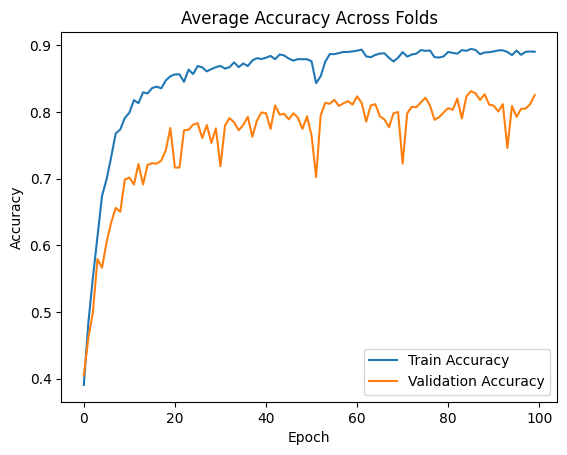

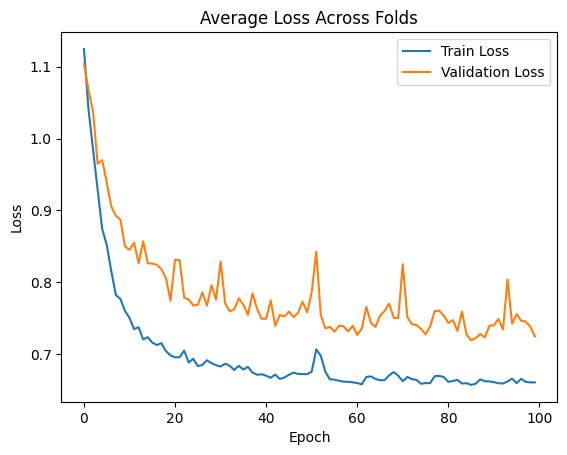

In [14]:
# Plot average accuracy
avg_train_acc = np.mean([np.array(result["train_accuracy"]) for result in results], axis=0)
avg_val_acc = np.mean([np.array(result["val_accuracy"]) for result in results], axis=0)
plt.figure()
plt.plot(avg_train_acc, label="Train Accuracy")
plt.plot(avg_val_acc, label="Validation Accuracy")
plt.title("Average Accuracy Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("average_accuracy.pdf")

# Plot best model accuracy
best_result = results[best_fold]
plt.figure()
plt.plot(best_result["train_accuracy"], label="Train Accuracy")
plt.plot(best_result["val_accuracy"], label="Validation Accuracy")
plt.title("Best Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("best_model_accuracy.pdf")

# Plot average loss
avg_train_loss = np.mean([np.array(result["train_loss"]) for result in results], axis=0)
avg_val_loss = np.mean([np.array(result["val_loss"]) for result in results], axis=0)
plt.figure()
plt.plot(avg_train_loss, label="Train Loss")
plt.plot(avg_val_loss, label="Validation Loss")
plt.title("Average Loss Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("average_loss.pdf")

print("All plots saved as PDF.")

/opt/conda/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


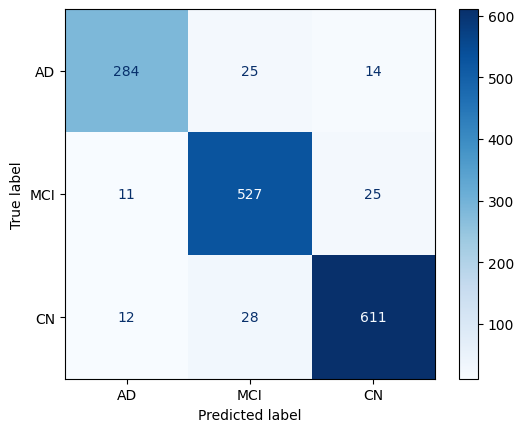


Classification Report:
              precision    recall  f1-score   support

          AD       0.93      0.88      0.90       323
         MCI       0.91      0.94      0.92       563
          CN       0.94      0.94      0.94       651

    accuracy                           0.93      1537
   macro avg       0.92      0.92      0.92      1537
weighted avg       0.93      0.93      0.93      1537



In [28]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# After your validation loop in each fold
all_labels = []
all_predictions = []

# Assuming you already have your validation loop defined, collect labels and predictions as follows
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.cuda(), labels.cuda()
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        # Append true labels and predictions
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['AD', 'MCI', 'CN'])  # Replace with your actual class names if needed
disp.plot(cmap=plt.cm.Blues)

# Save the confusion matrix plot
save_path = './confusion_matrix_fold.png'  # Replace with your desired file path
plt.savefig(save_path)

# Show plot
plt.show()

# Calculate precision, recall, and F1-score
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=['AD', 'MCI', 'CN']))  # Replace with your actual class names


In [29]:
# Save the best model
from pathlib import Path
Path('/kaggle/working/models').mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), 'last_model.pth')

# Visualize features

In [30]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [31]:
# Function to extract features and labels using the best model
def extract_features(model, dataloader):
    model.eval()  # Set the model to evaluation mode
    features, labels = [], []
    with torch.no_grad():
        for inputs, label_batch in dataloader:
            inputs = inputs.cuda()
            label_batch = label_batch.cuda()
            # Forward pass to get features (use model's penultimate layer or embeddings)
            output = model(inputs)
            feature_batch = output  # Change this if model has a specific feature extraction layer
            features.append(feature_batch.cpu().numpy())
            labels.append(label_batch.cpu().numpy())
    
    # Concatenate all features and labels
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

/opt/conda/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


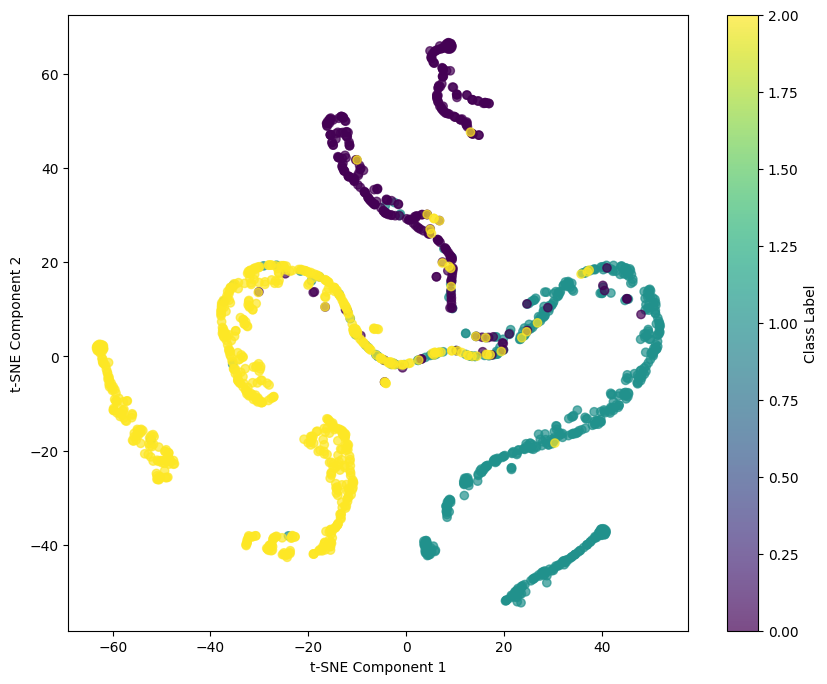

In [32]:
# Extract features and labels from validation set using the best model
best_model = hybrid_model.cuda()
best_model.load_state_dict(best_model_state)
features, labels = extract_features(best_model, val_loader)

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42,perplexity = 20)
tsne_features = tsne.fit_transform(features)

# Plot t-SNE features
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap="viridis", alpha=0.7)
plt.colorbar(scatter, label="Class Label")
# plt.title("t-SNE Visualization of Features (2 Components)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# Save plot as PDF
plt.savefig("tsne_visualization.pdf")
plt.show()